# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [ ]:
import os
gutenberg_dir = "D:/Proyectos/RI/01basicsearch/data/gutenberg_1000/"

def cargar_corpus_gutenberg(ruta_carpeta):
    """
    Lee todos los archivos .txt de la carpeta y devuelve:
        - documentos: lista de strings (contenido de cada libro)
        - nombres: lista con los nombres de los archivos
    """
    documentos = []
    nombres = []
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            with open(ruta_completa, 'r', encoding='utf-8') as f:
                contenido = f.read()
            documentos.append(contenido)
            nombres.append(archivo)
    return documentos, nombres

In [7]:
documentos_gutenberg, nombres_gutenberg = cargar_corpus_gutenberg(gutenberg_dir)
print(f"Se cargaron {len(documentos_gutenberg)} documentos.")

Se cargaron 1000 documentos.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [8]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter

# max_features limita el vocabulario a los términos más frecuentes para manejar mejor la memoria
vectorizer_count = CountVectorizer(max_features=5000, stop_words='english')

# Transformamos los documentos en una matriz de frecuencias de términos
# Cada fila es un documento, cada columna es un término
tf_matrix = vectorizer_count.fit_transform(documentos_gutenberg)

# Obtenemos el vocabulario (lista de términos únicos)
vocabulary = vectorizer_count.get_feature_names_out()

print(f"Dimensiones de la matriz TF: {tf_matrix.shape}")
print(f"(documentos x términos): {tf_matrix.shape[0]} x {tf_matrix.shape[1]}")

Dimensiones de la matriz TF: (1000, 5000)
(documentos x términos): 1000 x 5000


In [9]:
# Convertimos la matriz a binaria (0 o 1) para contar presencia, no frecuencia
df_vector = np.array((tf_matrix > 0).sum(axis=0)).flatten()

# Creamos un DataFrame para visualizar TF y DF de algunos términos
# Tomamos los primeros 10 documentos y 20 términos para la visualización
muestra_tf = tf_matrix[:10, :20].toarray()
muestra_df = df_vector[:20]

df_muestra = pd.DataFrame(
    muestra_tf,
    columns=vocabulary[:20],
    index=[f"Doc_{i}" for i in range(10)]
)

print("\nMuestra de matriz TF (primeros 10 docs, primeros 20 términos):")
print(df_muestra)

print("\nDocument Frequency (DF) de los primeros 20 términos:")
df_info = pd.DataFrame({
    'Término': vocabulary[:20],
    'DF (aparece en N documentos)': muestra_df
})
print(df_info)


Muestra de matriz TF (primeros 10 docs, primeros 20 términos):
       00  000  10  100  102  105  11  110  12  120  13  130  14  15  150  16  \
Doc_0   0    4   2    2    0    0   2    0   4    0   4    0   2   3    0   2   
Doc_1   0    0   0    0    0    0   0    0   0    0   0    0   0   0    0   0   
Doc_2   0    0   0    0    0    0   0    0   0    0   0    0   0   0    0   0   
Doc_3   0    0   0    0    0    0   0    0   0    0   0    0   0   0    0   0   
Doc_4   0    3   3    0    0    0   1    1   0    0   1    0   0   0    0   2   
Doc_5   0    0   1    0    0    0   1    0   1    0   1    0   1   1    0   1   
Doc_6   0    0   0    0    0    0   0    0   0    0   0    0   0   0    0   0   
Doc_7   0    0   1    0    0    0   0    0   0    0   0    0   0   0    1   0   
Doc_8   0    2   1    0    0    0   0    0   0    0   0    0   0   0    1   1   
Doc_9   0    0   1    0    0    0   1    0   0    0   1    0   1   0    0   0   

       17  18  1887  19  
Doc_0   2   2     

In [10]:
# usa la fórmula: TF-IDF(t,d) = TF(t,d) × IDF(t)
# donde IDF(t) = log((1 + N) / (1 + DF(t))) + 1 (fórmula de sklearn por defecto)
vectorizer_tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Generamos la matriz TF-IDF
tfidf_matrix = vectorizer_tfidf.fit_transform(documentos_gutenberg)

print(f"\nDimensiones de la matriz TF-IDF: {tfidf_matrix.shape}")


Dimensiones de la matriz TF-IDF: (1000, 5000)


In [11]:
N = len(documentos_gutenberg)  # Número total de documentos

# Calculamos IDF manualmente 
idf_manual = np.log((N - df_vector + 0.5) / (df_vector + 0.5))

# Obtenemos IDF de sklearn para comparar
idf_sklearn = vectorizer_tfidf.idf_

# Comparamos diferentes cálculos de IDF
df_idf_comparacion = pd.DataFrame({
    'Término': vocabulary[:20],
    'DF': df_vector[:20],
    'IDF (BM25 style)': idf_manual[:20],
    'IDF (sklearn)': idf_sklearn[:20]
})

print("Comparación de diferentes fórmulas de IDF:")
print(df_idf_comparacion)

Comparación de diferentes fórmulas de IDF:
   Término   DF  IDF (BM25 style)  IDF (sklearn)
0       00  123          1.960836       3.088473
1      000  709         -0.889520       1.343490
2       10  575         -0.301974       1.552647
3      100  377          0.501778       1.973861
4      102  198          1.396943       2.615450
5      105  215          1.293360       2.533476
6       11  516         -0.063958       1.660712
7      110  224          1.240921       2.492654
8       12  524         -0.095978       1.645357
9      120  262          1.034370       2.336601
10      13  476          0.095978       1.741238
11     130  226          1.229473       2.483805
12      14  477          0.091973       1.739144
13      15  512         -0.047961       1.668479
14     150  288          0.904085       2.242328
15      16  483          0.067958       1.726670
16      17  452          0.192400       1.792863
17      18  481          0.075961       1.730811
18    1887  506         -0

In [12]:
# Visualizamos TF-IDF de documentos de muestra
muestra_tfidf = tfidf_matrix[:5, :15].toarray()

df_tfidf_visual = pd.DataFrame(
    muestra_tfidf,
    columns=vocabulary[:15],
    index=[nombres_gutenberg[i][:30] for i in range(5)]  # Nombres de archivos truncados
)

print("Valores TF-IDF (primeros 5 docs, primeros 15 términos):")
print(df_tfidf_visual.round(3))

Valores TF-IDF (primeros 5 docs, primeros 15 términos):
                 00    000     10    100  102  105     11    110     12  120  \
book_10056.txt  0.0  0.003  0.002  0.002  0.0  0.0  0.002  0.000  0.004  0.0   
book_1010.txt   0.0  0.000  0.000  0.000  0.0  0.0  0.000  0.000  0.000  0.0   
book_1022.txt   0.0  0.000  0.000  0.000  0.0  0.0  0.000  0.000  0.000  0.0   
book_1035.txt   0.0  0.000  0.000  0.000  0.0  0.0  0.000  0.000  0.000  0.0   
book_10352.txt  0.0  0.001  0.001  0.000  0.0  0.0  0.000  0.001  0.000  0.0   

                   13  130     14     15  150  
book_10056.txt  0.004  0.0  0.002  0.003  0.0  
book_1010.txt   0.000  0.0  0.000  0.000  0.0  
book_1022.txt   0.000  0.0  0.000  0.000  0.0  
book_1035.txt   0.000  0.0  0.000  0.000  0.0  
book_10352.txt  0.000  0.0  0.000  0.000  0.0  


In [13]:
# Análisis: términos con mayor IDF (más distintivos)
terminos_raros = pd.DataFrame({
    'Término': vocabulary,
    'IDF': idf_sklearn
}).sort_values('IDF', ascending=False).head(20)

print("Top 20 términos más distintivos (mayor IDF):")
print(terminos_raros)

Top 20 términos más distintivos (mayor IDF):
      Término       IDF
112   _gould_  7.215608
1432    eders  7.215608
2084    havde  7.215608
2130  herrens  7.215608
2557   leaues  7.215608
4393      søn  6.810142
3045      når  6.810142
3848    sagde  6.810142
4767     være  6.810142
3053      obj  6.810142
1127      daz  6.810142
2400      jeg  6.522460
4102     skal  6.522460
558      blev  6.299317
2249     ikke  6.299317
2221     hvad  6.116995
1431     eder  6.116995
1679    farai  6.116995
4168  soorten  5.962845
4743     vnto  5.962845


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

query = "adventure journey"  
print(f"Consulta: '{query}'")

# Transformamos la consulta usando el mismo vectorizador TF-IDF
# Esto asegura que use el mismo vocabulario y ponderación
query_vector = vectorizer_tfidf.transform([query])
print(f"Vector de consulta creado con dimensión: {query_vector.shape}")

Consulta: 'adventure journey'
Vector de consulta creado con dimensión: (1, 5000)


In [17]:
# La similitud coseno mide el ángulo entre vectores
# Valores cercanos a 1 = muy similares, cercanos a 0 = diferentes
similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

print(f"Se calcularon {len(similarities)} similitudes")

# Ordenamos los documentos por similitud de mayor a menor
ranking_indices = np.argsort(similarities)[::-1]
# Creamos un DataFrame con los top resultados
top_n = 15

resultados_tfidf = pd.DataFrame({
    'Rank': range(1, top_n + 1),
    'Documento': [nombres_gutenberg[i] for i in ranking_indices[:top_n]],
    'Similitud Coseno': similarities[ranking_indices[:top_n]],
    'Fragmento': [documentos_gutenberg[i][:100].replace('\n', ' ') for i in ranking_indices[:top_n]]
})

print(f"Top {top_n} documentos más relevantes para la consulta '{query}':")
print(resultados_tfidf.to_string(index=False))

Se calcularon 1000 similitudes
Top 15 documentos más relevantes para la consulta 'adventure journey':
 Rank      Documento  Similitud Coseno                                                                                            Fragmento
    1  book_4328.txt          0.065712 The Project Gutenberg EBook of Two Expeditions into the Interior of  Southern Australia, Volume I, b
    2 book_20638.txt          0.060694 The Project Gutenberg EBook of From Plotzk to Boston, by Mary Antin    This eBook is for the use of 
    3 book_71961.txt          0.053299 ﻿  *** START OF THE PROJECT GUTENBERG EBOOK JOURNAL OF A SECOND EXPEDITION INTO THE INTERIOR OF AFRI
    4 book_74281.txt          0.047657 ﻿  *** START OF THE PROJECT GUTENBERG EBOOK 74281 ***        [Illustration: Emil Holub        _Front
    5 book_69806.txt          0.040113 *** START OF THE PROJECT GUTENBERG EBOOK 69806 ***                            THE CIRCE OF THE      
    6 book_58281.txt          0.039889 ﻿The Project Gutenb

###  Análisis de distribución de similitudes

In [18]:
print("Estadísticas de similitud:")
print(f"  • Similitud máxima: {similarities.max():.4f}")
print(f"  • Similitud promedio: {similarities.mean():.4f}")
print(f"  • Similitud mínima: {similarities.min():.4f}")
print(f"  • Documentos con similitud > 0: {(similarities > 0).sum()}")

Estadísticas de similitud:
  • Similitud máxima: 0.0657
  • Similitud promedio: 0.0041
  • Similitud mínima: 0.0000
  • Documentos con similitud > 0: 575


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [19]:
from collections import defaultdict
import math

# Usaremos la misma consulta anterior
print(f"Consulta para BM25: '{query}'")

# PASO 1: Tokenización simple
def tokenizar(texto):
    """
    Convierte el texto en tokens (palabras) en minúsculas.
    Elimina puntuación básica.
    """
    import re
    # Convertimos a minúsculas y extraemos palabras
    tokens = re.findall(r'\b[a-z]+\b', texto.lower())
    return tokens

# Tokenizamos todos los documentos
documentos_tokenizados = [tokenizar(doc) for doc in documentos_gutenberg]
query_tokens = tokenizar(query)

print(f"Documentos tokenizados")
print(f"Consulta tokenizada: {query_tokens}")

Consulta para BM25: 'adventure journey'
Documentos tokenizados
Consulta tokenizada: ['adventure', 'journey']


In [20]:
# |d| = longitud de cada documento (número de términos)
doc_lengths = np.array([len(doc) for doc in documentos_tokenizados])
avgdl = doc_lengths.mean()  # Longitud promedio de documentos

print(f"Longitudes de documentos:")
print(f"  • Longitud promedio (avgdl): {avgdl:.2f} términos")
print(f"  • Longitud mínima: {doc_lengths.min()} términos")
print(f"  • Longitud máxima: {doc_lengths.max()} términos")

Longitudes de documentos:
  • Longitud promedio (avgdl): 58826.64 términos
  • Longitud mínima: 1699 términos
  • Longitud máxima: 1379754 términos


In [21]:
# TF[i][t] = frecuencia del término t en el documento i
doc_term_freqs = []
for doc_tokens in documentos_tokenizados:
    # Counter cuenta la frecuencia de cada término en el documento
    term_freq = Counter(doc_tokens)
    doc_term_freqs.append(term_freq)

print(f"TF calculado para {len(doc_term_freqs)} documentos")

TF calculado para 1000 documentos


In [22]:
# Construimos el vocabulario y DF
vocab_bm25 = set()
df_bm25 = defaultdict(int)

for doc_tokens in documentos_tokenizados:
    # Usamos set para contar cada término solo una vez por documento
    unique_terms = set(doc_tokens)
    for term in unique_terms:
        vocab_bm25.add(term)
        df_bm25[term] += 1

N = len(documentos_gutenberg)  # Número total de documentos

# Calculamos IDF para cada término
# Esta es la fórmula de IDF de BM25 (Robertson-Sparck Jones)
idf_bm25 = {}
for term in vocab_bm25:
    # IDF = log((N - DF + 0.5) / (DF + 0.5))
    # Penaliza términos muy comunes (alto DF) y realza términos raros (bajo DF)
    idf_bm25[term] = math.log((N - df_bm25[term] + 0.5) / (df_bm25[term] + 0.5))

print(f"Vocabulario BM25: {len(vocab_bm25)} términos únicos")
print(f"IDF calculado para todos los términos")

Vocabulario BM25: 685825 términos únicos
IDF calculado para todos los términos


In [24]:
print("IDF de los términos de la consulta:")
for term in query_tokens:
    if term in idf_bm25:
        print(f"  • '{term}': IDF = {idf_bm25[term]:.4f}, aparece en {df_bm25[term]} documentos")
    else:
        print(f"  • '{term}': NO aparece en el corpus")

# Definir parámetros de BM25
# k1 controla la saturación de TF (típicamente entre 1.2 y 2.0)
# b controla la normalización por longitud (típicamente 0.75)
k1 = 1.5
b = 0.75

print(f"Parámetros BM25:")
print(f"  • k1 (saturación TF) = {k1}")
print(f"  • b (normalización longitud) = {b}")

IDF de los términos de la consulta:
  • 'adventure': IDF = 0.6096, aparece en 352 documentos
  • 'journey': IDF = -0.1000, aparece en 525 documentos
Parámetros BM25:
  • k1 (saturación TF) = 1.5
  • b (normalización longitud) = 0.75


In [26]:
# Función de score BM25 para un documento
def bm25_score(query_tokens, doc_index, doc_term_freqs, idf_bm25, doc_lengths, avgdl, k1, b):
 
    # Calcula el score BM25 de un documento dado una consulta.

    score = 0.0
    doc_len = doc_lengths[doc_index]
    term_freqs = doc_term_freqs[doc_index]
    
    # Calculamos la normalización por longitud
    # Esto penaliza documentos largos que repiten términos
    normalization = k1 * ((1 - b) + b * (doc_len / avgdl))
    
    for term in query_tokens:
        if term in idf_bm25:  # El término existe en el corpus
            tf = term_freqs.get(term, 0)  # Frecuencia del término en este documento
            
            # Componente de saturación de TF
            # A medida que TF crece, la ganancia marginal disminuye (efecto de saturación)
            tf_component = ((k1 + 1) * tf) / (normalization + tf)
            
            # Multiplicamos por IDF
            score += idf_bm25[term] * tf_component
    
    return score

In [27]:

# Calcular BM25 para todos los documentos
bm25_scores = np.array([
    bm25_score(query_tokens, i, doc_term_freqs, idf_bm25, doc_lengths, avgdl, k1, b)
    for i in range(len(documentos_gutenberg))
])

print(f"Scores BM25 calculados para {len(bm25_scores)} documentos")

Scores BM25 calculados para 1000 documentos


In [28]:
# Generar ranking BM25
ranking_bm25_indices = np.argsort(bm25_scores)[::-1]

# Crear tabla de resultados BM25
resultados_bm25 = pd.DataFrame({
    'Rank': range(1, top_n + 1),
    'Documento': [nombres_gutenberg[i] for i in ranking_bm25_indices[:top_n]],
    'Score BM25': bm25_scores[ranking_bm25_indices[:top_n]],
    'Fragmento': [documentos_gutenberg[i][:100].replace('\n', ' ') for i in ranking_bm25_indices[:top_n]]
})

print(f"Top {top_n} documentos según BM25 para '{query}':")
print(resultados_bm25.to_string(index=False))

# Estadísticas BM25
print("Estadísticas de scores BM25:")
print(f"  • Score máximo: {bm25_scores.max():.4f}")
print(f"  • Score promedio: {bm25_scores.mean():.4f}")
print(f"  • Score mínimo: {bm25_scores.min():.4f}")
print(f"  • Documentos con score > 0: {(bm25_scores > 0).sum()}")

Top 15 documentos según BM25 para 'adventure journey':
 Rank      Documento  Score BM25                                                                                            Fragmento
    1 book_54993.txt    1.348792 *** START OF THE PROJECT GUTENBERG EBOOK 54993 ***    [Illustration:      Erastus F. Beadle    David
    2 book_32931.txt    1.328463 The Project Gutenberg EBook of Harley Greenoak's Charge, by Bertram Mitford    This eBook is for the
    3  book_1252.txt    1.278913 F*** START OF THE PROJECT GUTENBERG EBOOK 1252 ***  Le Morte D’Arthur King Arthur and of his Noble K
    4  book_1022.txt    1.266346 *** START OF THE PROJECT GUTENBERG EBOOK 1022 ***    WALKING    by Henry David Thoreau          I wi
    5  book_2776.txt    1.243843 ﻿The Project Gutenberg eBook of The Four Million, by O. Henry    This eBook is for the use of anyone
    6 book_69114.txt    1.228742 *** START OF THE PROJECT GUTENBERG EBOOK 69114 ***                                      OUR         
    7  

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

In [29]:
import matplotlib.pyplot as plt

# Normalizamos BM25 dividiendo por el score máximo
bm25_normalized = bm25_scores / bm25_scores.max() if bm25_scores.max() > 0 else bm25_scores

# Creamos un DataFrame comparativo con los top documentos
top_compare = 15

# Obtenemos los índices de los documentos únicos que aparecen en top de alguno de los dos
top_tfidf_set = set(ranking_indices[:top_compare])
top_bm25_set = set(ranking_bm25_indices[:top_compare])
docs_to_compare = sorted(top_tfidf_set | top_bm25_set)[:top_compare]

# Creamos el DataFrame de comparación
df_comparacion = pd.DataFrame({
    'Documento': [nombres_gutenberg[i][:40] for i in docs_to_compare],
    'TF-IDF': similarities[docs_to_compare],
    'BM25': bm25_normalized[docs_to_compare],
    'Score BM25 (original)': bm25_scores[docs_to_compare]
})

print("Tabla comparativa TF-IDF vs BM25 (scores normalizados):")
print(df_comparacion.to_string(index=False))

Tabla comparativa TF-IDF vs BM25 (scores normalizados):
     Documento   TF-IDF      BM25  Score BM25 (original)
 book_1022.txt 0.022121  0.938874               1.266346
book_11308.txt 0.029241  0.890465               1.201053
book_11876.txt 0.004651  0.878004               1.184246
 book_1252.txt 0.009973  0.948191               1.278913
book_20291.txt 0.033931  0.623858               0.841455
book_20638.txt 0.060694 -0.179705              -0.242385
 book_2119.txt 0.012050  0.876939               1.182808
 book_2693.txt 0.006740  0.883287               1.191371
 book_2728.txt 0.039004  0.781641               1.054271
 book_2776.txt 0.018315  0.922190               1.243843
book_28905.txt 0.000924  0.880329               1.187380
book_32931.txt 0.011255  0.984928               1.328463
book_35676.txt 0.029254  0.713951               0.962971
book_36422.txt 0.031339  0.669891               0.903543
 book_4328.txt 0.065712  0.215875               0.291170


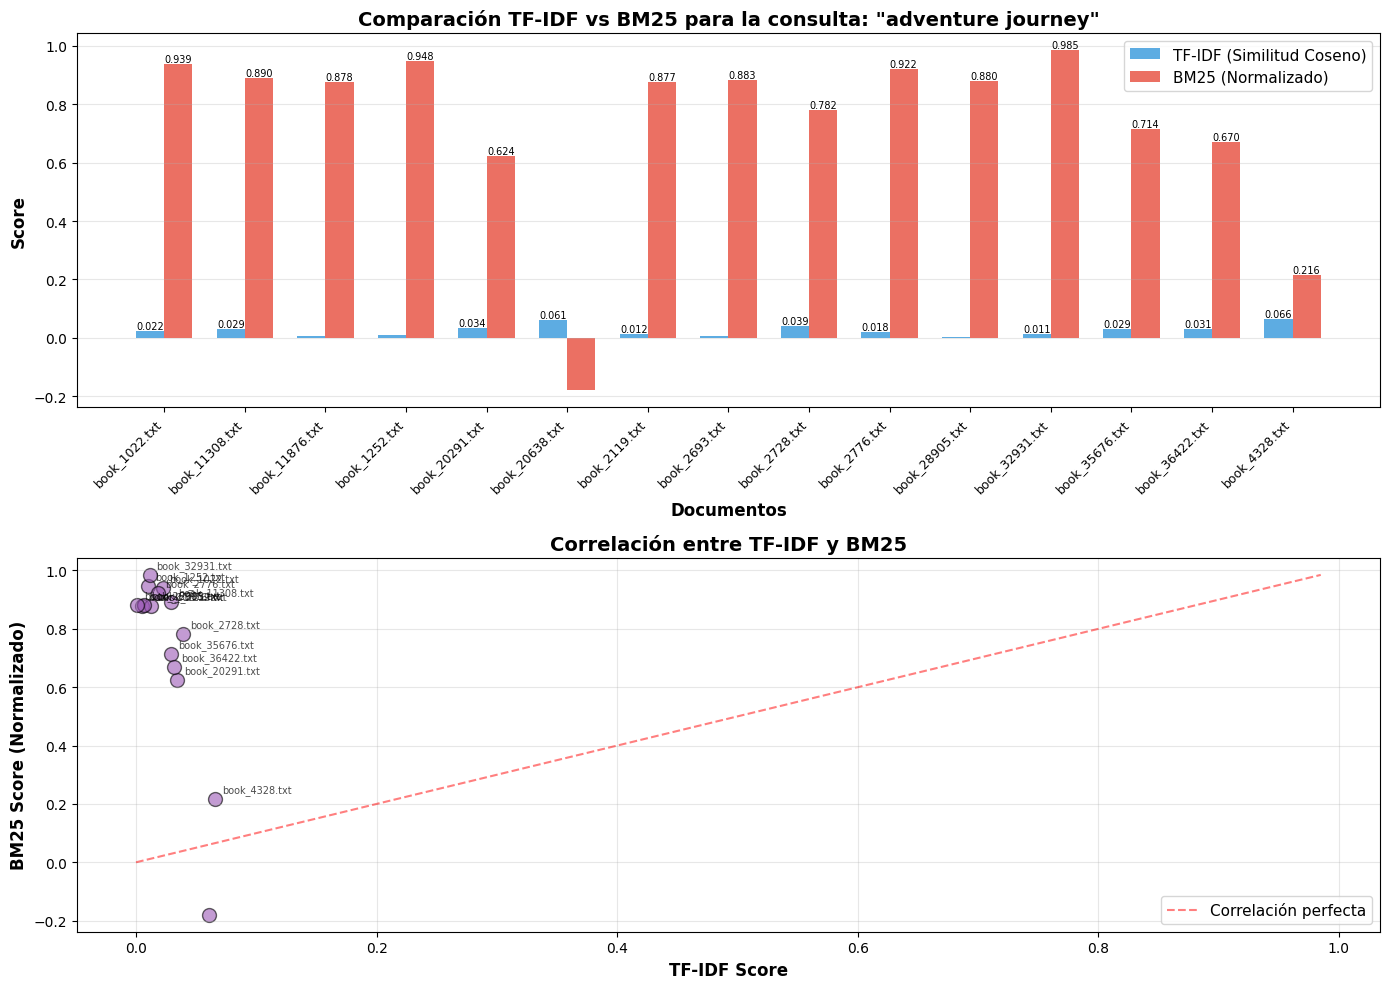

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Comparación lado a lado
x = np.arange(len(docs_to_compare))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, df_comparacion['TF-IDF'], width, 
                label='TF-IDF (Similitud Coseno)', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_comparacion['BM25'], width, 
                label='BM25 (Normalizado)', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('Documentos', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Comparación TF-IDF vs BM25 para la consulta: "{query}"', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_comparacion['Documento'], rotation=45, ha='right', fontsize=9)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Añadimos valores encima de las barras
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    if height1 > 0.01:
        ax1.text(bar1.get_x() + bar1.get_width()/2., height1,
                f'{height1:.3f}', ha='center', va='bottom', fontsize=7)
    if height2 > 0.01:
        ax1.text(bar2.get_x() + bar2.get_width()/2., height2,
                f'{height2:.3f}', ha='center', va='bottom', fontsize=7)



# Gráfico 2: Scatter plot de correlación
ax2 = axes[1]
ax2.scatter(df_comparacion['TF-IDF'], df_comparacion['BM25'], 
           s=100, alpha=0.6, c='#9b59b6', edgecolors='black', linewidth=1)

# Añadimos etiquetas a los puntos más relevantes
for idx, row in df_comparacion.iterrows():
    if row['TF-IDF'] > 0.1 or row['BM25'] > 0.1:  # Solo etiquetamos puntos importantes
        ax2.annotate(row['Documento'][:20], 
                    (row['TF-IDF'], row['BM25']),
                    fontsize=7, alpha=0.7, 
                    xytext=(5, 5), textcoords='offset points')

# Línea de referencia (correlación perfecta)
max_val = max(df_comparacion['TF-IDF'].max(), df_comparacion['BM25'].max())
ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Correlación perfecta')

ax2.set_xlabel('TF-IDF Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('BM25 Score (Normalizado)', fontsize=12, fontweight='bold')
ax2.set_title('Correlación entre TF-IDF y BM25', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analisis de Diferencia

In [35]:
# Calculamos la diferencia de ranking
ranking_changes = []
for i in range(min(top_compare, len(docs_to_compare))):
    doc_idx = docs_to_compare[i]
    tfidf_rank = np.where(ranking_indices == doc_idx)[0][0] + 1
    bm25_rank = np.where(ranking_bm25_indices == doc_idx)[0][0] + 1
    diff = tfidf_rank - bm25_rank
    
    ranking_changes.append({
        'Documento': nombres_gutenberg[doc_idx][:50],
        'Rank TF-IDF': tfidf_rank,
        'Rank BM25': bm25_rank,
        'Diferencia': diff
    })

df_ranking_changes = pd.DataFrame(ranking_changes).sort_values('Diferencia', 
                                                                key=abs, 
                                                                ascending=False)

print("Documentos con mayor cambio de ranking:")
print(df_ranking_changes.head(10).to_string(index=False))

Documentos con mayor cambio de ranking:
     Documento  Rank TF-IDF  Rank BM25  Diferencia
book_20638.txt            2        999        -997
book_28905.txt          535         12         523
 book_4328.txt            1        327        -326
book_11876.txt          301         13         288
 book_2693.txt          216         11         205
book_20291.txt            9        133        -124
 book_1252.txt          122          3         119
book_36422.txt           11        109         -98
book_32931.txt          100          2          98
 book_2119.txt           91         14          77


In [37]:
# Documentos que BM25 rankea mucho mejor
mejores_bm25 = df_ranking_changes[df_ranking_changes['Diferencia'] > 5].head(5)
if not mejores_bm25.empty:
    print("Documentos rankeados MEJOR por BM25:")
    for _, row in mejores_bm25.iterrows():
        print(f"  • {row['Documento']}")
        print(f"    TF-IDF: rank #{row['Rank TF-IDF']} → BM25: rank #{row['Rank BM25']} "
              f"(mejora de {row['Diferencia']} posiciones)")
else:
    print("  No hay documentos significativamente mejor rankeados por BM25")

# Documentos que TF-IDF rankea mucho mejor
mejores_tfidf = df_ranking_changes[df_ranking_changes['Diferencia'] < -5].head(5)
if not mejores_tfidf.empty:
    print("Documentos rankeados MEJOR por TF-IDF:")
    for _, row in mejores_tfidf.iterrows():
        print(f"  • {row['Documento']}")
        print(f"    TF-IDF: rank #{row['Rank TF-IDF']} ← BM25: rank #{row['Rank BM25']} "
              f"(mejora de {abs(row['Diferencia'])} posiciones)")
else:
    print("  No hay documentos significativamente mejor rankeados por TF-IDF")

Documentos rankeados MEJOR por BM25:
  • book_28905.txt
    TF-IDF: rank #535 → BM25: rank #12 (mejora de 523 posiciones)
  • book_11876.txt
    TF-IDF: rank #301 → BM25: rank #13 (mejora de 288 posiciones)
  • book_2693.txt
    TF-IDF: rank #216 → BM25: rank #11 (mejora de 205 posiciones)
  • book_1252.txt
    TF-IDF: rank #122 → BM25: rank #3 (mejora de 119 posiciones)
  • book_32931.txt
    TF-IDF: rank #100 → BM25: rank #2 (mejora de 98 posiciones)
Documentos rankeados MEJOR por TF-IDF:
  • book_20638.txt
    TF-IDF: rank #2 ← BM25: rank #999 (mejora de 997 posiciones)
  • book_4328.txt
    TF-IDF: rank #1 ← BM25: rank #327 (mejora de 326 posiciones)
  • book_20291.txt
    TF-IDF: rank #9 ← BM25: rank #133 (mejora de 124 posiciones)
  • book_36422.txt
    TF-IDF: rank #11 ← BM25: rank #109 (mejora de 98 posiciones)
  • book_35676.txt
    TF-IDF: rank #12 ← BM25: rank #82 (mejora de 70 posiciones)


In [38]:
# Calculamos correlación
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(df_comparacion['TF-IDF'], df_comparacion['BM25'])
spearman_corr, spearman_p = spearmanr(df_comparacion['TF-IDF'], df_comparacion['BM25'])

print(f"CORRELACIÓN ENTRE MODELOS:")
print(f"  • Correlación de Pearson: {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
print(f"  • Correlación de Spearman: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")

if spearman_corr > 0.8:
    print("Alta correlación: los modelos rankean de forma muy similar")
elif spearman_corr > 0.5:
    print("Correlación moderada: hay diferencias notables en el ranking")
else:
    print("Baja correlación: los modelos rankean de forma bastante diferente")


CORRELACIÓN ENTRE MODELOS:
  • Correlación de Pearson: -0.8511 (p-value: 5.7425e-05)
  • Correlación de Spearman: -0.6893 (p-value: 4.4737e-03)
Baja correlación: los modelos rankean de forma bastante diferente
